# MELD Suitability Analysis for CDM/CIM

Notebook này kiểm tra xem MELD có phù hợp để chạy các thí nghiệm **Baseline / CDM / CIM / CDM+CIM** không, đặc biệt là chất lượng tín hiệu thời gian (`StartTime`, `EndTime`) để dùng cho Conversational Interaction Memory.

Mục tiêu chính:

- Kiểm tra schema và coverage timestamp.
- Phân tích dialogue length, speaker switch, gap, overlap.
- Tính 4 interaction features đang dùng trong kiến trúc chốt.
- Xem phân bố theo split, season, emotion.
- Đưa ra suitability score cho CDM và CIM.


## 1. Setup


In [1]:
from __future__ import annotations

import json
import os
import re
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "matplotlib"))

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    display
except NameError:
    def display(value):
        print(value)

sns.set_theme(style="whitegrid", context="paper")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists() or ((candidate / "configs").exists() and (candidate / "scripts").exists()):
            return candidate
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
MELD_ROOT_CANDIDATES = [
    PROJECT_ROOT / "data" / "meld" / "MELD-RAW" / "MELD.Raw",
    PROJECT_ROOT / "data" / "meld-dataset" / "MELD-RAW" / "MELD.Raw",
]
MELD_ROOT = next((p for p in MELD_ROOT_CANDIDATES if p.exists()), MELD_ROOT_CANDIDATES[0])
OUT_DIR = PROJECT_ROOT / "reports" / "meld_suitability"
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("MELD_ROOT    =", MELD_ROOT)
print("OUT_DIR      =", OUT_DIR)


PROJECT_ROOT = /Users/ngocbao/Documents/Document/research/main/speech/exps/demo
MELD_ROOT    = /Users/ngocbao/Documents/Document/research/main/speech/exps/demo/data/meld/MELD-RAW/MELD.Raw
OUT_DIR      = /Users/ngocbao/Documents/Document/research/main/speech/exps/demo/reports/meld_suitability


## 2. Load MELD CSVs


In [2]:
SPLIT_FILES = {
    "train": MELD_ROOT / "train" / "train_sent_emo.csv",
    "dev": MELD_ROOT / "dev_sent_emo.csv",
    "test": MELD_ROOT / "test_sent_emo.csv",
}

frames = []
missing = []
for split, path in SPLIT_FILES.items():
    if not path.exists():
        missing.append(str(path))
        continue
    df = pd.read_csv(path)
    df["split"] = split
    frames.append(df)

if not frames:
    raise FileNotFoundError("No MELD sent_emo CSV files found. Checked:\n" + "\n".join(map(str, SPLIT_FILES.values())))
if missing:
    print("Missing files:")
    for item in missing:
        print("-", item)

raw_df = pd.concat(frames, ignore_index=True)
raw_df.columns = [str(c).strip() for c in raw_df.columns]
raw_df["dialogue_key"] = raw_df["split"].astype(str) + "_d" + raw_df["Dialogue_ID"].astype(str)
raw_df["episode_key"] = raw_df["Season"].astype(str) + "x" + raw_df["Episode"].astype(str)

print(raw_df.shape)
display(raw_df.head())
display(raw_df.groupby("split").size().rename("utterances").reset_index())
raw_df.to_csv(OUT_DIR / "meld_raw_loaded.csv", index=False)


(13708, 14)


,Sr No.,Utterance,Speaker,Emotion,Sentiment,Dialogue_ID,Utterance_ID,Season,Episode,StartTime,EndTime,split,dialogue_key,episode_key
0,1,also I was the point person on my companys tr...,Chandler,neutral,neutral,0,0,8,21,"00:16:16,059","00:16:21,731",train,train_d0,8x21
1,2,You mustve had your hands full.,The Interviewer,neutral,neutral,0,1,8,21,"00:16:21,940","00:16:23,442",train,train_d0,8x21
2,3,That I did. That I did.,Chandler,neutral,neutral,0,2,8,21,"00:16:23,442","00:16:26,389",train,train_d0,8x21
3,4,So lets talk a little bit about your duties.,The Interviewer,neutral,neutral,0,3,8,21,"00:16:26,820","00:16:29,572",train,train_d0,8x21
4,5,My duties? All right.,Chandler,surprise,positive,0,4,8,21,"00:16:34,452","00:16:40,917",train,train_d0,8x21


,split,utterances
0,dev,1109
1,test,2610
2,train,9989


## 3. Timestamp Parsing and Sanity Checks


In [3]:
def parse_meld_time(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if not text:
        return np.nan
    # MELD uses HH:MM:SS,mmm.
    match = re.match(r"^(\d+):(\d+):(\d+),(\d+)$", text)
    if not match:
        return np.nan
    hours, minutes, seconds, millis = map(int, match.groups())
    return hours * 3600.0 + minutes * 60.0 + seconds + millis / 1000.0


df = raw_df.copy()
df["start_time"] = df["StartTime"].map(parse_meld_time)
df["end_time"] = df["EndTime"].map(parse_meld_time)
df["duration"] = df["end_time"] - df["start_time"]
df["has_valid_time"] = df["start_time"].notna() & df["end_time"].notna() & (df["duration"] >= 0)

coverage = pd.DataFrame([
    {"metric": "utterances", "value": len(df)},
    {"metric": "dialogues", "value": df["dialogue_key"].nunique()},
    {"metric": "valid_time_rate", "value": df["has_valid_time"].mean()},
    {"metric": "negative_duration_count", "value": int((df["duration"] < 0).sum())},
    {"metric": "zero_duration_count", "value": int((df["duration"] == 0).sum())},
])
display(coverage)
coverage.to_csv(OUT_DIR / "timestamp_coverage.csv", index=False)

bad_time = df.loc[~df["has_valid_time"], ["split", "Dialogue_ID", "Utterance_ID", "StartTime", "EndTime", "duration"]]
print("Bad timestamp rows:", len(bad_time))
if len(bad_time):
    display(bad_time.head(20))


,metric,value
0,utterances,13708.0
1,dialogues,1432.0
2,valid_time_rate,1.0
3,negative_duration_count,0.0
4,zero_duration_count,1.0


Bad timestamp rows: 0


## 4. Dialogue-Level Temporal Features

Các feature chính dùng để kiểm tra CIM:

- `relative_gap_to_speaker_mean`: gap hiện tại so với lịch sử gap của cùng speaker.
- `overlap_ratio`: lượng overlap với utterance trước, chuẩn hóa theo duration hiện tại.
- `speaker_switch`: turn hiện tại có đổi speaker so với turn trước không.
- `speaker_prev_overlap_rate`: speaker này trước đó có xu hướng overlap/chen lời không.


In [4]:
def add_dialogue_temporal_features(group: pd.DataFrame) -> pd.DataFrame:
    group = group.sort_values(["Utterance_ID", "start_time", "end_time"]).copy()
    rows = []
    speaker_history = {}
    previous = None
    max_len = max(len(group), 1)
    for turn_index, (_, row) in enumerate(group.iterrows()):
        start = float(row["start_time"]) if pd.notna(row["start_time"]) else np.nan
        end = float(row["end_time"]) if pd.notna(row["end_time"]) else np.nan
        duration = max(0.0, end - start) if pd.notna(start) and pd.notna(end) else np.nan
        speaker = str(row["Speaker"])
        if previous is None or pd.isna(start) or pd.isna(previous["end_time"]):
            gap_prev = 0.0
            overlap_prev = 0.0
            speaker_switch = 0.0
            has_previous = False
            previous_speaker = None
        else:
            prev_end = float(previous["end_time"])
            gap_prev = start - prev_end
            overlap_prev = max(0.0, prev_end - start)
            previous_speaker = str(previous["Speaker"])
            speaker_switch = 1.0 if speaker != previous_speaker else 0.0
            has_previous = True

        history = speaker_history.get(speaker, {
            "turn_count": 0.0,
            "overlap_count": 0.0,
            "gap_sum": 0.0,
            "duration_sum": 0.0,
        })
        prev_turns = history["turn_count"]
        speaker_prev_mean_gap = history["gap_sum"] / max(prev_turns, 1.0)
        speaker_prev_overlap_rate = history["overlap_count"] / max(prev_turns, 1.0)
        relative_gap_to_speaker_mean = gap_prev - speaker_prev_mean_gap if prev_turns > 0 else 0.0
        overlap_ratio = overlap_prev / max(duration if pd.notna(duration) else 0.0, 1e-6)
        is_overlap = 1.0 if has_previous and overlap_prev > 0.05 else 0.0

        item = row.to_dict()
        item.update({
            "turn_index": turn_index,
            "turn_index_norm": turn_index / max_len,
            "duration": duration,
            "gap_prev": gap_prev,
            "overlap_prev": overlap_prev,
            "overlap_ratio": overlap_ratio,
            "is_overlap": is_overlap,
            "speaker_switch": speaker_switch,
            "speaker_prev_mean_gap": speaker_prev_mean_gap,
            "speaker_prev_overlap_rate": speaker_prev_overlap_rate,
            "relative_gap_to_speaker_mean": relative_gap_to_speaker_mean,
        })
        rows.append(item)

        history["turn_count"] += 1.0
        history["overlap_count"] += is_overlap
        history["gap_sum"] += gap_prev
        history["duration_sum"] += duration if pd.notna(duration) else 0.0
        speaker_history[speaker] = history
        previous = item
    return pd.DataFrame(rows)

feature_groups = []
for _, group in df.groupby(["split", "Dialogue_ID"], sort=False, dropna=False):
    feature_groups.append(add_dialogue_temporal_features(group))
feature_df = pd.concat(feature_groups, ignore_index=True) if feature_groups else df.iloc[0:0].copy()
feature_df["valid_gap"] = feature_df["has_valid_time"] & feature_df["gap_prev"].notna()
feature_df.to_csv(OUT_DIR / "meld_temporal_features.csv", index=False)

feature_cols = [
    "duration", "gap_prev", "overlap_prev", "overlap_ratio",
    "speaker_switch", "speaker_prev_overlap_rate", "relative_gap_to_speaker_mean",
]
display(feature_df[["split", "dialogue_key", "Utterance_ID", "Speaker", "Emotion", *feature_cols]].head(10))


,split,dialogue_key,Utterance_ID,Speaker,Emotion,duration,gap_prev,overlap_prev,overlap_ratio,speaker_switch,speaker_prev_overlap_rate,relative_gap_to_speaker_mean
0,train,train_d0,0,Chandler,neutral,5.672,0.000,0.000,0.000000,0.0,0.00,0.000000
1,train,train_d0,1,The Interviewer,neutral,1.502,0.209,0.000,0.000000,1.0,0.00,0.000000
2,train,train_d0,2,Chandler,neutral,2.947,0.000,0.000,0.000000,1.0,0.00,0.000000
3,train,train_d0,3,The Interviewer,neutral,2.752,0.431,0.000,0.000000,1.0,0.00,0.222000
4,train,train_d0,4,Chandler,surprise,6.465,4.880,0.000,0.000000,1.0,0.00,4.880000
5,train,train_d0,5,The Interviewer,neutral,3.211,0.209,0.000,0.000000,1.0,0.00,-0.111000
6,train,train_d0,6,Chandler,neutral,3.086,4.463,0.000,0.000000,1.0,0.00,2.836333
7,train,train_d0,7,The Interviewer,neutral,5.714,-3.086,3.086,0.540077,1.0,0.00,-3.369000
8,train,train_d0,8,Chandler,neutral,1.001,4.963,0.000,0.000000,1.0,0.00,2.627250
9,train,train_d0,9,The Interviewer,neutral,2.241,0.000,0.000,0.000000,1.0,0.25,0.559250


## 5. Dialogue Structure: CDM Suitability


,split,dialogues,mean_utterances,median_utterances,pct_dialogues_len_ge_3,mean_speakers,mean_switch_rate
0,dev,114,9.728070,10.0,0.912281,3.008772,0.665074
1,test,280,9.321429,9.0,0.896429,2.664286,0.627996
2,train,1038,9.623314,9.0,0.874759,2.711946,0.628635


,split,dialogue_key,utterances,speakers,emotions,duration_total,switch_rate
193,test,test_d17,33,7,6,120.311,0.696970
824,train,train_d450,24,4,4,107.333,0.708333
923,train,train_d54,24,4,6,102.317,0.666667
905,train,train_d523,24,6,5,52.460,0.916667
913,train,train_d530,24,2,4,76.771,0.458333
1043,train,train_d649,24,2,4,90.423,0.541667
1257,train,train_d841,23,3,5,63.503,0.782609
199,test,test_d175,23,2,6,61.381,0.782609
144,test,test_d125,23,3,5,45.062,0.391304
1381,train,train_d953,23,2,5,58.809,0.608696


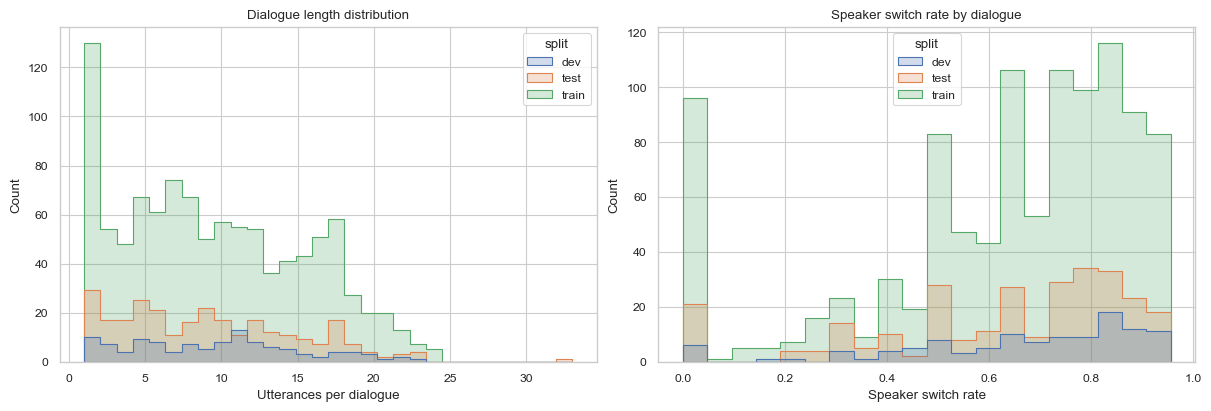

Saved /Users/ngocbao/Documents/Document/research/main/speech/exps/demo/reports/meld_suitability/figures/dialogue_structure.png


In [5]:
dialogue_stats = feature_df.groupby(["split", "dialogue_key"]).agg(
    utterances=("Utterance_ID", "count"),
    speakers=("Speaker", "nunique"),
    emotions=("Emotion", "nunique"),
    duration_total=("duration", "sum"),
    switch_rate=("speaker_switch", "mean"),
).reset_index()

dialogue_summary = dialogue_stats.groupby("split").agg(
    dialogues=("dialogue_key", "count"),
    mean_utterances=("utterances", "mean"),
    median_utterances=("utterances", "median"),
    pct_dialogues_len_ge_3=("utterances", lambda s: float((s >= 3).mean())),
    mean_speakers=("speakers", "mean"),
    mean_switch_rate=("switch_rate", "mean"),
).reset_index()

display(dialogue_summary)
display(dialogue_stats.sort_values("utterances", ascending=False).head(15))
dialogue_stats.to_csv(OUT_DIR / "dialogue_stats.csv", index=False)
dialogue_summary.to_csv(OUT_DIR / "dialogue_summary.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
sns.histplot(data=dialogue_stats, x="utterances", hue="split", bins=30, ax=axes[0], element="step")
axes[0].set_title("Dialogue length distribution")
axes[0].set_xlabel("Utterances per dialogue")
sns.histplot(data=dialogue_stats, x="switch_rate", hue="split", bins=20, ax=axes[1], element="step")
axes[1].set_title("Speaker switch rate by dialogue")
axes[1].set_xlabel("Speaker switch rate")
fig_path = FIG_DIR / "dialogue_structure.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved", fig_path)


## 6. Temporal Interaction Distribution: CIM Suitability


,split,utterances,valid_time_rate,mean_duration,median_duration,mean_gap,median_gap,negative_gap_rate,overlap_rate,strong_overlap_rate,speaker_switch_rate
0,dev,1109,1.0,3.117356,2.454,1.250300,0.168,0.059513,0.057710,0.050496,0.706041
1,test,2610,1.0,3.308830,2.460,2.525174,0.168,0.040230,0.039847,0.031801,0.676245
2,train,9989,1.0,3.138593,2.460,1.297870,0.168,0.065172,0.065072,0.056262,0.694864


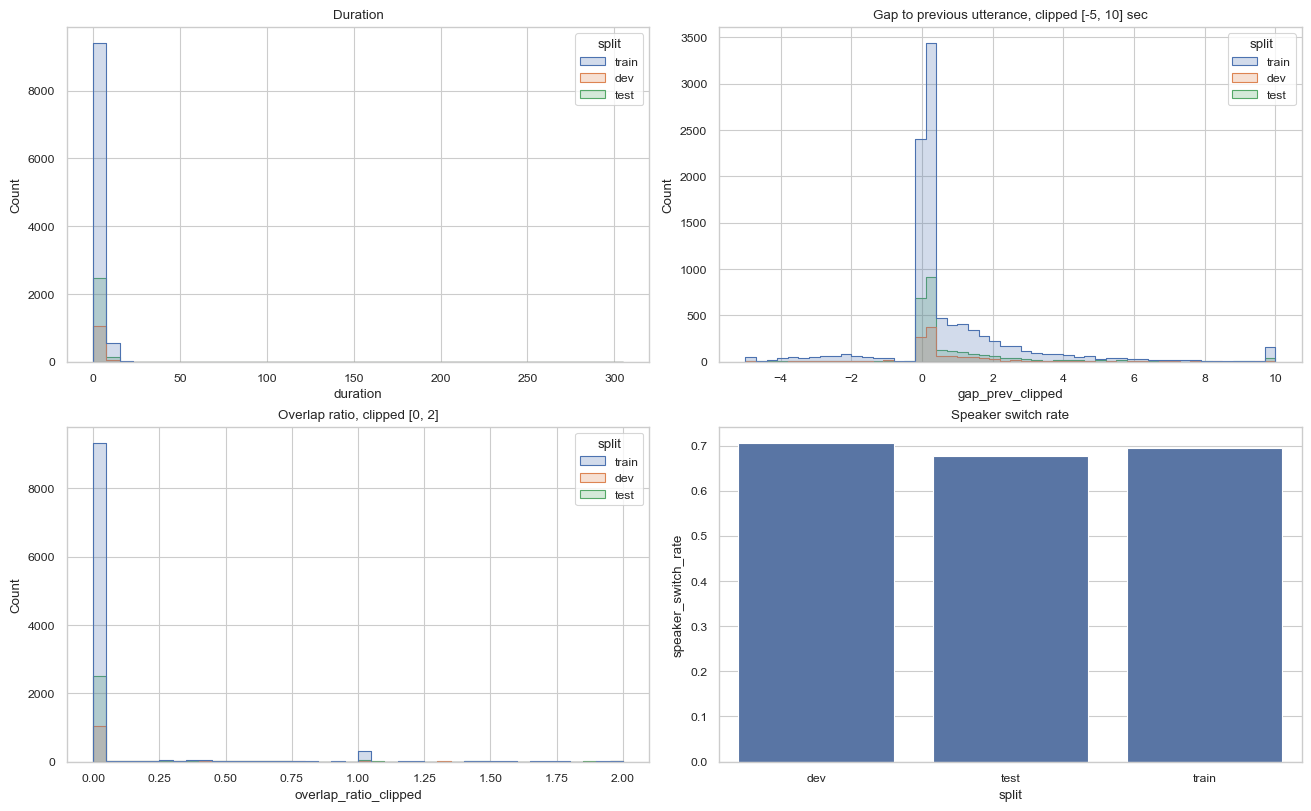

Saved /Users/ngocbao/Documents/Document/research/main/speech/exps/demo/reports/meld_suitability/figures/temporal_interaction_distribution.png


In [6]:
interaction_cols = ["duration", "gap_prev", "overlap_prev", "overlap_ratio", "speaker_switch", "speaker_prev_overlap_rate", "relative_gap_to_speaker_mean"]
interaction_summary = feature_df.groupby("split").agg(
    utterances=("Utterance_ID", "count"),
    valid_time_rate=("has_valid_time", "mean"),
    mean_duration=("duration", "mean"),
    median_duration=("duration", "median"),
    mean_gap=("gap_prev", "mean"),
    median_gap=("gap_prev", "median"),
    negative_gap_rate=("gap_prev", lambda s: float((s < 0).mean())),
    overlap_rate=("overlap_prev", lambda s: float((s > 0.05).mean())),
    strong_overlap_rate=("overlap_ratio", lambda s: float((s >= 0.30).mean())),
    speaker_switch_rate=("speaker_switch", "mean"),
).reset_index()

display(interaction_summary)
interaction_summary.to_csv(OUT_DIR / "interaction_summary.csv", index=False)

plot_df = feature_df.copy()
# Clip only for visualization; CSV keeps raw values.
plot_df["gap_prev_clipped"] = plot_df["gap_prev"].clip(-5, 10)
plot_df["overlap_ratio_clipped"] = plot_df["overlap_ratio"].clip(0, 2)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
sns.histplot(data=plot_df, x="duration", hue="split", bins=40, ax=axes[0,0], element="step")
axes[0,0].set_title("Duration")
sns.histplot(data=plot_df, x="gap_prev_clipped", hue="split", bins=50, ax=axes[0,1], element="step")
axes[0,1].set_title("Gap to previous utterance, clipped [-5, 10] sec")
sns.histplot(data=plot_df, x="overlap_ratio_clipped", hue="split", bins=40, ax=axes[1,0], element="step")
axes[1,0].set_title("Overlap ratio, clipped [0, 2]")
sns.barplot(data=interaction_summary, x="split", y="speaker_switch_rate", ax=axes[1,1])
axes[1,1].set_title("Speaker switch rate")
fig_path = FIG_DIR / "temporal_interaction_distribution.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved", fig_path)


## 7. Feature Distribution by Emotion and Season


,Emotion,duration_mean,duration_median,duration_std,duration_count,gap_prev_mean,gap_prev_median,gap_prev_std,gap_prev_count,overlap_prev_mean,overlap_prev_median,overlap_prev_std,overlap_prev_count,overlap_ratio_mean,overlap_ratio_median,overlap_ratio_std,overlap_ratio_count,speaker_switch_mean,speaker_switch_median,speaker_switch_std,speaker_switch_count,speaker_prev_overlap_rate_mean,speaker_prev_overlap_rate_median,speaker_prev_overlap_rate_std,speaker_prev_overlap_rate_count,relative_gap_to_speaker_mean_mean,relative_gap_to_speaker_mean_median,relative_gap_to_speaker_mean_std,relative_gap_to_speaker_mean_count
4,neutral,3.004901,2.3760,2.274286,6436,1.687711,0.168,25.114506,6436,0.232802,0.0,4.459107,6436,0.061507,0.0,1.073518,6436,0.693288,1.0,0.461165,6436,0.036326,0.0,0.127081,6436,0.059446,0.0,12.280030,6436
3,joy,3.366634,2.5010,6.827523,2308,1.485914,0.168,16.375865,2308,0.176620,0.0,0.780398,2308,0.048779,0.0,0.256815,2308,0.698440,1.0,0.459035,2308,0.029667,0.0,0.114077,2308,0.285390,0.0,12.558605,2308
6,surprise,2.695918,2.0480,2.171195,1636,1.691177,0.209,20.988327,1636,0.171884,0.0,0.707549,1636,0.058975,0.0,0.264818,1636,0.793399,1.0,0.404991,1636,0.033934,0.0,0.128646,1636,0.387923,0.0,25.256116,1636
0,anger,3.335882,2.7520,2.436621,1607,0.753578,0.168,4.511375,1607,0.183190,0.0,0.805012,1607,0.050495,0.0,0.316830,1607,0.618544,1.0,0.485895,1607,0.036351,0.0,0.111698,1607,-0.711020,0.0,17.156618,1607
5,sadness,3.783505,2.9615,2.648632,1002,1.483402,0.168,20.517404,1002,0.197496,0.0,0.772934,1002,0.045874,0.0,0.187055,1002,0.626747,1.0,0.483910,1002,0.043659,0.0,0.136444,1002,-0.112193,0.0,5.747683,1002
1,disgust,4.404917,3.0450,12.461304,361,2.374942,0.168,29.795920,361,0.161471,0.0,0.766388,361,0.034923,0.0,0.169303,361,0.731302,1.0,0.443898,361,0.042805,0.0,0.129134,361,0.023339,0.0,4.646728,361
2,fear,3.302620,2.6275,2.300746,358,0.917925,0.168,2.690247,358,0.114696,0.0,0.605224,358,0.028845,0.0,0.155844,358,0.645251,1.0,0.479107,358,0.031762,0.0,0.131016,358,-1.330350,0.0,26.451671,358


,Season,duration_mean,duration_median,duration_std,duration_count,gap_prev_mean,gap_prev_median,gap_prev_std,gap_prev_count,overlap_prev_mean,overlap_prev_median,overlap_prev_std,overlap_prev_count,overlap_ratio_mean,overlap_ratio_median,overlap_ratio_std,overlap_ratio_count,speaker_switch_mean,speaker_switch_median,speaker_switch_std,speaker_switch_count,speaker_prev_overlap_rate_mean,speaker_prev_overlap_rate_median,speaker_prev_overlap_rate_std,speaker_prev_overlap_rate_count,relative_gap_to_speaker_mean_mean,relative_gap_to_speaker_mean_median,relative_gap_to_speaker_mean_std,relative_gap_to_speaker_mean_count
0,1,3.088746,2.376,2.427263,1830,2.123193,0.209,29.599228,1830,0.139574,0.0,0.643493,1830,0.049985,0.0,0.333251,1830,0.691803,1.0,0.461875,1830,0.034031,0.0,0.125559,1830,0.101891,0.0,4.331885,1830
1,2,3.651777,2.422,11.577544,417,1.770564,0.209,8.098253,417,0.136878,0.0,0.597952,417,0.051831,0.0,0.239381,417,0.666667,1.0,0.471971,417,0.027562,0.0,0.115070,417,-0.032408,0.0,9.340168,417
2,3,3.327040,2.460,6.798618,2270,1.238970,0.168,15.124298,2270,0.241655,0.0,2.665014,2270,0.081649,0.0,1.537685,2270,0.700000,1.0,0.458359,2270,0.037950,0.0,0.131444,2270,-0.527770,0.0,17.282140,2270
3,4,3.207114,2.467,2.586712,1543,0.978701,0.168,2.998808,1543,0.146704,0.0,0.690247,1543,0.039128,0.0,0.201319,1543,0.694102,1.0,0.460936,1543,0.030457,0.0,0.113852,1543,0.159405,0.0,2.855903,1543
4,5,2.882090,2.251,2.199639,1741,1.666952,0.210,17.214915,1741,0.103885,0.0,0.547026,1741,0.031043,0.0,0.165208,1741,0.679495,1.0,0.466805,1741,0.027244,0.0,0.106073,1741,-0.109178,0.0,18.299588,1741
5,6,3.062039,2.460,2.267656,1981,1.918247,0.168,20.645711,1981,0.181180,0.0,0.779021,1981,0.045448,0.0,0.199074,1981,0.678445,1.0,0.467191,1981,0.036568,0.0,0.118062,1981,0.223614,0.0,18.957175,1981
6,7,3.214274,2.502,2.460211,1711,0.969405,0.168,12.658044,1711,0.418638,0.0,8.062946,1711,0.078591,0.0,1.080463,1711,0.712449,1.0,0.452753,1711,0.039044,0.0,0.126401,1711,-0.197177,0.0,13.258560,1711
7,8,3.271106,2.627,2.567107,1588,1.264285,0.167,22.190629,1588,0.203227,0.0,0.820924,1588,0.052699,0.0,0.232154,1588,0.698992,1.0,0.458840,1588,0.044185,0.0,0.144746,1588,0.472254,0.0,22.214853,1588
8,9,3.174944,2.668,2.189124,627,2.594568,0.168,50.474497,627,0.179541,0.0,0.733355,627,0.054115,0.0,0.227886,627,0.684211,1.0,0.465201,627,0.036699,0.0,0.128648,627,0.106394,0.0,1.915940,627


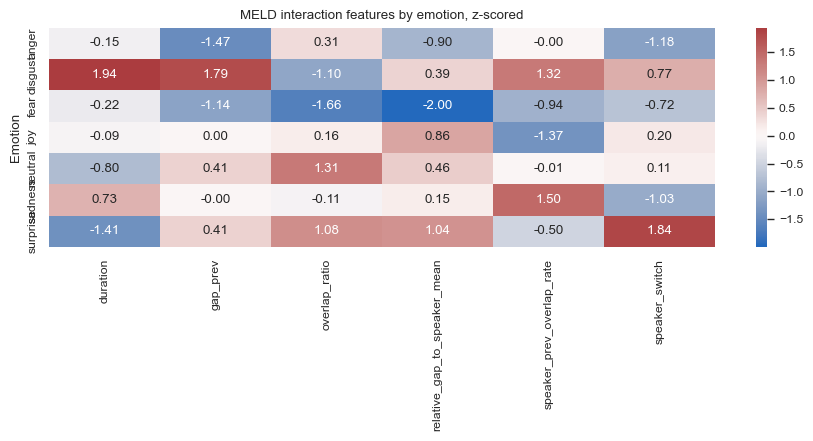

Saved /Users/ngocbao/Documents/Document/research/main/speech/exps/demo/reports/meld_suitability/figures/feature_by_emotion_heatmap.png


In [7]:
feature_by_emotion = feature_df.groupby("Emotion")[interaction_cols].agg(["mean", "median", "std", "count"])
feature_by_emotion.columns = ["_".join(col).strip("_") for col in feature_by_emotion.columns.to_flat_index()]
feature_by_emotion = feature_by_emotion.reset_index().sort_values("duration_count", ascending=False)
display(feature_by_emotion)
feature_by_emotion.to_csv(OUT_DIR / "feature_by_emotion.csv", index=False)

feature_by_season = feature_df.groupby("Season")[interaction_cols].agg(["mean", "median", "std", "count"])
feature_by_season.columns = ["_".join(col).strip("_") for col in feature_by_season.columns.to_flat_index()]
feature_by_season = feature_by_season.reset_index()
display(feature_by_season)
feature_by_season.to_csv(OUT_DIR / "feature_by_season.csv", index=False)

heatmap_data = feature_df.pivot_table(
    index="Emotion",
    values=["duration", "gap_prev", "overlap_ratio", "speaker_switch", "speaker_prev_overlap_rate", "relative_gap_to_speaker_mean"],
    aggfunc="mean",
)
# Robust z-score across emotions for readability.
heatmap_z = (heatmap_data - heatmap_data.mean()) / heatmap_data.std(ddof=0).replace(0, np.nan)
plt.figure(figsize=(9, 4.5))
sns.heatmap(heatmap_z, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("MELD interaction features by emotion, z-scored")
plt.tight_layout()
fig_path = FIG_DIR / "feature_by_emotion_heatmap.png"
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved", fig_path)


## 8. Correlation and Redundancy of Interaction Features


,duration,gap_prev,overlap_ratio,speaker_switch,speaker_prev_overlap_rate,relative_gap_to_speaker_mean,turn_index_norm
duration,1.000000,0.088009,0.156008,-0.042526,-0.000731,0.022928,0.002863
gap_prev,0.088009,1.000000,-0.414013,0.274190,0.013894,0.535270,0.230549
overlap_ratio,0.156008,-0.414013,1.000000,0.017419,0.030411,-0.318443,0.050273
speaker_switch,-0.042526,0.274190,0.017419,1.000000,-0.013446,0.048149,0.258192
speaker_prev_overlap_rate,-0.000731,0.013894,0.030411,-0.013446,1.000000,0.215245,0.248596
relative_gap_to_speaker_mean,0.022928,0.535270,-0.318443,0.048149,0.215245,1.000000,-0.041071
turn_index_norm,0.002863,0.230549,0.050273,0.258192,0.248596,-0.041071,1.000000


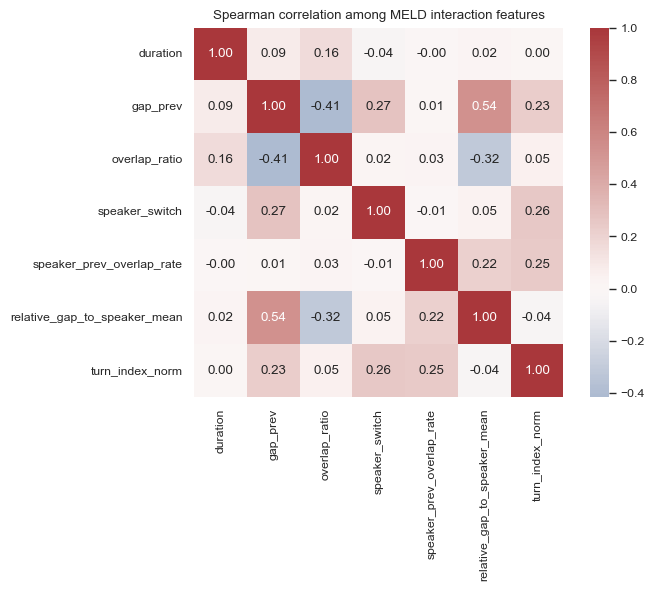

Saved /Users/ngocbao/Documents/Document/research/main/speech/exps/demo/reports/meld_suitability/figures/interaction_feature_correlation.png


In [8]:
corr_cols = ["duration", "gap_prev", "overlap_ratio", "speaker_switch", "speaker_prev_overlap_rate", "relative_gap_to_speaker_mean", "turn_index_norm"]
corr = feature_df[corr_cols].corr(method="spearman")
display(corr)
corr.to_csv(OUT_DIR / "interaction_feature_spearman_correlation.csv")

plt.figure(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Spearman correlation among MELD interaction features")
plt.tight_layout()
fig_path = FIG_DIR / "interaction_feature_correlation.png"
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved", fig_path)


## 9. Suitability Score and Recommendation


In [9]:
valid_time_rate = float(feature_df["has_valid_time"].mean())
mean_dialogue_len = float(dialogue_stats["utterances"].mean())
pct_len_ge_3 = float((dialogue_stats["utterances"] >= 3).mean())
speaker_switch_rate = float(feature_df["speaker_switch"].mean())
overlap_rate = float((feature_df["overlap_prev"] > 0.05).mean())
strong_overlap_rate = float((feature_df["overlap_ratio"] >= 0.30).mean())
negative_gap_rate = float((feature_df["gap_prev"] < 0).mean())
nontrivial_gap_rate = float((feature_df["gap_prev"].abs() > 0.05).mean())

# Simple interpretable scores, not model metrics.
cdm_score = (
    0.40 * min(mean_dialogue_len / 5.0, 1.0)
    + 0.30 * pct_len_ge_3
    + 0.30 * speaker_switch_rate
)
cim_score = (
    0.35 * valid_time_rate
    + 0.20 * min(nontrivial_gap_rate / 0.7, 1.0)
    + 0.20 * min((overlap_rate + negative_gap_rate) / 0.25, 1.0)
    + 0.15 * speaker_switch_rate
    + 0.10 * min(strong_overlap_rate / 0.1, 1.0)
)

recommendation = []
if cdm_score >= 0.65:
    recommendation.append("CDM: suitable. MELD has enough dialogue structure and speaker turns.")
elif cdm_score >= 0.45:
    recommendation.append("CDM: moderately suitable. Dialogue context exists, but dialogue length/speaker diversity should be checked.")
else:
    recommendation.append("CDM: weak suitability. Many dialogues may be too short or low-interaction.")

if cim_score >= 0.65:
    recommendation.append("CIM: suitable enough to test. Timestamp-derived interaction cues appear non-trivial.")
elif cim_score >= 0.45:
    recommendation.append("CIM: possible but risky. Use as a generalization/robustness experiment and report timestamp limitations.")
else:
    recommendation.append("CIM: weak suitability. Timing signals may be too sparse/noisy for a strong claim.")

suitability = {
    "valid_time_rate": valid_time_rate,
    "mean_dialogue_len": mean_dialogue_len,
    "pct_dialogues_len_ge_3": pct_len_ge_3,
    "speaker_switch_rate": speaker_switch_rate,
    "overlap_rate": overlap_rate,
    "strong_overlap_rate": strong_overlap_rate,
    "negative_gap_rate": negative_gap_rate,
    "nontrivial_gap_rate": nontrivial_gap_rate,
    "cdm_suitability_score": cdm_score,
    "cim_suitability_score": cim_score,
    "recommendation": recommendation,
}

suitability_df = pd.DataFrame([
    {"metric": key, "value": value}
    for key, value in suitability.items()
    if key != "recommendation"
])
display(suitability_df)
for line in recommendation:
    print("-", line)

(OUT_DIR / "suitability_summary.json").write_text(json.dumps(suitability, ensure_ascii=False, indent=2), encoding="utf-8")
suitability_df.to_csv(OUT_DIR / "suitability_summary.csv", index=False)


,metric,value
0,valid_time_rate,1.000000
1,mean_dialogue_len,9.572626
2,pct_dialogues_len_ge_3,0.881983
3,speaker_switch_rate,0.692224
4,overlap_rate,0.059673
5,strong_overlap_rate,0.051138
6,negative_gap_rate,0.059965
7,nontrivial_gap_rate,0.764590
8,cdm_suitability_score,0.872262
9,cim_suitability_score,0.800682


- CDM: suitable. MELD has enough dialogue structure and speaker turns.
- CIM: suitable enough to test. Timestamp-derived interaction cues appear non-trivial.


## 10. Saved Outputs


In [10]:
outputs = sorted(p.relative_to(OUT_DIR) for p in OUT_DIR.rglob("*") if p.is_file())
print(f"Saved {len(outputs)} files under {OUT_DIR}")
for path in outputs:
    print(path)


Saved 15 files under /Users/ngocbao/Documents/Document/research/main/speech/exps/demo/reports/meld_suitability
dialogue_stats.csv
dialogue_summary.csv
feature_by_emotion.csv
feature_by_season.csv
figures/dialogue_structure.png
figures/feature_by_emotion_heatmap.png
figures/interaction_feature_correlation.png
figures/temporal_interaction_distribution.png
interaction_feature_spearman_correlation.csv
interaction_summary.csv
meld_raw_loaded.csv
meld_temporal_features.csv
suitability_summary.csv
suitability_summary.json
timestamp_coverage.csv
